# Joint Angle Verification Notebook

This notebook verifies that the joint angle calculations are working correctly through:

1. **Visual inspection** - Animated stick figures with angle overlays
2. **Anatomical range validation** - Check angles stay within physiological limits
3. **Continuity checks** - Detect sudden jumps suggesting calculation errors
4. **DTW similarity analysis** - Verify within/between subject patterns

### Key Hypothesis
- Within-subject, same-condition comparisons should be most similar
- The "fun" condition may show high variability (kids rolling on floor, etc.)
- Between-subject similarity in constrained conditions (control/fast) might exceed within-subject similarity across conditions

In [1]:
import sys
sys.path.insert(0, 'src')
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from processing.mocap_loader import MocapDataLoader
from joint_angles import (
    calculate_all_joint_angles, 
    convert_angles_to_ndarray,
    get_marker_position,
    get_angle_labels
)

print("Imports successful!")

Imports successful!


## 1. Load Data

In [3]:
# Load motion capture data
loader = MocapDataLoader(Path('~/github_projects/hopscotch/marker_labels_no_floor.txt').expanduser())
raw_data = loader.load_dataset(
    Path('~/github_projects/hopscotch/data').expanduser(),
    file_pattern='*.tsv',
    cache_file='hopscotch_data_no_floor2.feather'
)
print(raw_data.columns)

print(f"Loaded {len(raw_data)} total frames")
print(f"Subjects: {sorted(raw_data['subject'].unique())}")
print(f"Conditions: {sorted(raw_data['condition'].unique())}")
print(f"Obstacles: {sorted(raw_data['obstacles'].unique())}")

Index(['Frame', 'Time', 'head.X', 'head.Y', 'head.Z', 'foot_front_r.X',
       'foot_front_r.Y', 'foot_front_r.Z', 'foot_back_r.X', 'foot_back_r.Y',
       'foot_back_r.Z', 'knee_under_r.X', 'knee_under_r.Y', 'knee_under_r.Z',
       'knee_over_r.X', 'knee_over_r.Y', 'knee_over_r.Z', 'wrist_r.X',
       'wrist_r.Y', 'wrist_r.Z', 'elbow_r.X', 'elbow_r.Y', 'elbow_r.Z',
       'shoulder_r.X', 'shoulder_r.Y', 'shoulder_r.Z', 'hip_front_r.X',
       'hip_front_r.Y', 'hip_front_r.Z', 'hip_back_r.X', 'hip_back_r.Y',
       'hip_back_r.Z', 'foot_back_l.X', 'foot_back_l.Y', 'foot_back_l.Z',
       'foot_front_l.X', 'foot_front_l.Y', 'foot_front_l.Z', 'knee_under_l.X',
       'knee_under_l.Y', 'knee_under_l.Z', 'knee_over_l.X', 'knee_over_l.Y',
       'knee_over_l.Z', 'hip_front_l.X', 'hip_front_l.Y', 'hip_front_l.Z',
       'hip_back_l.X', 'hip_back_l.Y', 'hip_back_l.Z', 'wrist_l.X',
       'wrist_l.Y', 'wrist_l.Z', 'elbow_l.X', 'elbow_l.Y', 'elbow_l.Z',
       'shoulder_l.X', 'shoulder_l.Y', '

In [4]:
# Helper function to get a specific trial
def get_trial(subject, condition, obstacles):
    """Extract a single trial's data."""
    mask = (
        (raw_data['subject'] == subject) & 
        (raw_data['condition'] == condition) & 
        (raw_data['obstacles'] == obstacles)
    )
    return raw_data[mask].copy().reset_index(drop=True)

# Get a sample trial for visualization
subjects = sorted(raw_data['subject'].unique())
conditions = sorted(raw_data['condition'].unique())
sample_trial = get_trial(subjects[0], conditions[0], 'uden')
print(f"Sample trial: subject={subjects[0]}, condition={conditions[0]}, frames={len(sample_trial)}")

Sample trial: subject=33, condition=h, frames=0


## 2. Define Skeleton Structure for Visualization

In [5]:
# Define skeleton connections for visualization
SKELETON_CONNECTIONS = [
    # Spine/torso
    ('hip_front_l', 'hip_front_r'),
    ('hip_back_l', 'hip_back_r'),
    ('hip_front_l', 'hip_back_l'),
    ('hip_front_r', 'hip_back_r'),
    
    # Right arm
    ('shoulder_r', 'elbow_r'),
    ('elbow_r', 'wrist_r'),
    
    # Left arm
    ('shoulder_l', 'elbow_l'),
    ('elbow_l', 'wrist_l'),
    
    # Right leg
    ('hip_front_r', 'knee_over_r'),
    ('hip_back_r', 'knee_over_r'),
    ('knee_over_r', 'knee_under_r'),
    ('knee_under_r', 'foot_front_r'),
    ('knee_under_r', 'foot_back_r'),
    ('foot_front_r', 'foot_back_r'),
    
    # Left leg
    ('hip_front_l', 'knee_over_l'),
    ('hip_back_l', 'knee_over_l'),
    ('knee_over_l', 'knee_under_l'),
    ('knee_under_l', 'foot_front_l'),
    ('knee_under_l', 'foot_back_l'),
    ('foot_front_l', 'foot_back_l'),
    
    # Shoulders
    ('shoulder_l', 'shoulder_r'),
    
    # Head
    ('shoulder_l', 'head'),
    ('shoulder_r', 'head'),
]

# Markers used for joint angle visualization
JOINT_MARKERS = {
    'elbow_r': ('shoulder_r', 'elbow_r', 'wrist_r'),
    'elbow_l': ('shoulder_l', 'elbow_l', 'wrist_l'),
    'knee_r': ('hip_front_r', 'knee_over_r', 'foot_front_r'),
    'knee_l': ('hip_front_l', 'knee_over_l', 'foot_front_l'),
}

print(f"Defined {len(SKELETON_CONNECTIONS)} skeleton connections")

Defined 23 skeleton connections


## 3. Visualize Skeleton with Joint Angles

### 3.1 Static Frame Visualization

In [7]:
def plot_skeleton_frame(trial_data, frame_idx, angles_df=None, ax=None, title=None):
    """
    Plot a single frame of the skeleton in 3D.
    
    Args:
        trial_data: DataFrame with marker positions
        frame_idx: Frame index to plot
        angles_df: Optional DataFrame with joint angles for annotation
        ax: Optional matplotlib 3D axis
        title: Optional title
    """
    if ax is None:
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
    
    # Plot skeleton connections
    for m1, m2 in SKELETON_CONNECTIONS:
        try:
            p1 = get_marker_position(trial_data, m1, frame_idx)
            p2 = get_marker_position(trial_data, m2, frame_idx)
            if len(p1) > 0 and len(p2) > 0:
                ax.plot([p1[0], p2[0]], [p1[2], p2[2]], [p1[1], p2[1]], 
                       'b-', linewidth=2, alpha=0.7)
        except:
            pass
    
    # Plot joint markers with angle coloring
    if angles_df is not None:
        for joint_name, (m1, m2, m3) in JOINT_MARKERS.items():
            try:
                p2 = get_marker_position(trial_data, m2, frame_idx)  # Joint center
                angle_deg = np.degrees(angles_df[joint_name].iloc[frame_idx])
                
                # Color based on angle (green=extended, red=flexed)
                color = plt.cm.RdYlGn(1 - angle_deg / 180)
                ax.scatter([p2[0]], [p2[2]], [p2[1]], c=[color], s=100, 
                          edgecolors='black', linewidth=1)
                ax.text(p2[0], p2[2], p2[1] + 50, f'{angle_deg:.0f}°', 
                       fontsize=8, ha='center')
            except:
                pass
    
    # Set axis properties
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Z (mm)')
    ax.set_zlabel('Y (mm)')
    
    if title:
        ax.set_title(title)
    
    # Set equal aspect ratio
    all_markers = ['hip_front_l', 'hip_front_r', 'shoulder_l', 'shoulder_r', 'head']
    positions = []
    for m in all_markers:
        try:
            p = get_marker_position(trial_data, m, frame_idx)
            if len(p) > 0:
                positions.append(p)
        except:
            pass
    
    if positions:
        positions = np.array(positions)
        center = positions.mean(axis=0)
        max_range = np.max(np.abs(positions - center)) * 1.5
        ax.set_xlim(center[0] - max_range, center[0] + max_range)
        ax.set_ylim(center[2] - max_range, center[2] + max_range)
        ax.set_zlim(center[1] - max_range, center[1] + max_range)
    
    return ax

In [8]:
# Calculate angles for sample trial
sample_angles = calculate_all_joint_angles(sample_trial)
print(f"Calculated {len(sample_angles.columns)} angle columns")
print(f"Columns: {list(sample_angles.columns)}")

Calculated 20 angle columns
Columns: ['frame', 'time', 'elbow_r', 'elbow_l', 'knee_r', 'knee_l', 'ankle_r', 'ankle_l', 'shoulder_r_elevation', 'shoulder_r_azimuth', 'shoulder_l_elevation', 'shoulder_l_azimuth', 'hip_r_flexion', 'hip_r_abduction', 'hip_l_flexion', 'hip_l_abduction', 'trunk_forward_lean', 'trunk_lateral_lean', 'head_forward', 'head_lateral']


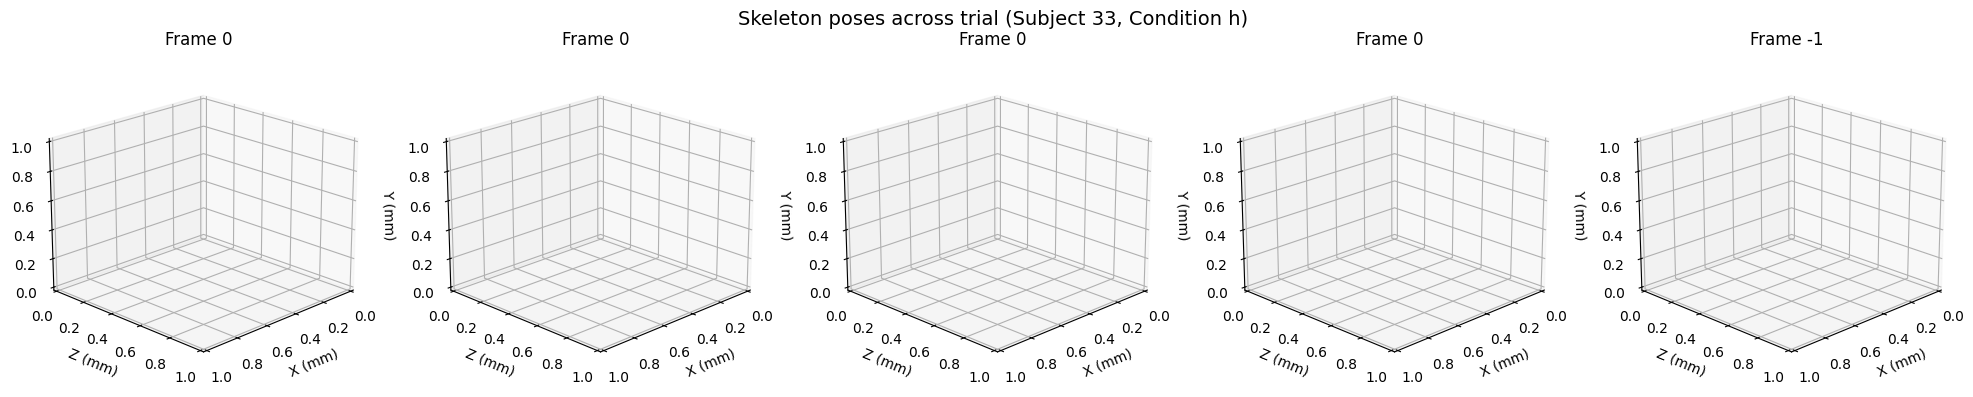

In [9]:
# Plot multiple frames to see pose variation
n_frames = len(sample_trial)
frame_indices = [0, n_frames//4, n_frames//2, 3*n_frames//4, n_frames-1]

fig = plt.figure(figsize=(20, 4))
for i, frame_idx in enumerate(frame_indices):
    ax = fig.add_subplot(1, 5, i+1, projection='3d')
    plot_skeleton_frame(sample_trial, frame_idx, sample_angles, ax, 
                       title=f'Frame {frame_idx}')
    ax.view_init(elev=20, azim=45)

plt.suptitle(f'Skeleton poses across trial (Subject {subjects[0]}, Condition {conditions[0]})', 
            fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Animated Skeleton

In [10]:
def create_skeleton_animation(trial_data, angles_df, skip_frames=10, max_frames=200):
    """
    Create an animated 3D skeleton visualization.
    
    Args:
        trial_data: DataFrame with marker positions
        angles_df: DataFrame with joint angles
        skip_frames: Subsample every N frames for speed
        max_frames: Maximum frames to animate
    """
    n_frames = min(len(trial_data), max_frames * skip_frames)
    frame_indices = list(range(0, n_frames, skip_frames))
    
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Pre-calculate axis limits from all frames
    all_positions = []
    for m in ['hip_front_l', 'hip_front_r', 'shoulder_l', 'shoulder_r', 'head',
              'wrist_l', 'wrist_r', 'foot_front_l', 'foot_front_r']:
        try:
            pos = get_marker_position(trial_data, m)
            if len(pos) > 0:
                all_positions.append(pos)
        except:
            pass
    
    all_positions = np.vstack(all_positions)
    center = all_positions.mean(axis=0)
    max_range = np.max(np.abs(all_positions - center)) * 1.2
    
    def init():
        ax.clear()
        return []
    
    def update(frame_num):
        ax.clear()
        frame_idx = frame_indices[frame_num]
        
        # Plot skeleton
        for m1, m2 in SKELETON_CONNECTIONS:
            try:
                p1 = get_marker_position(trial_data, m1, frame_idx)
                p2 = get_marker_position(trial_data, m2, frame_idx)
                if len(p1) > 0 and len(p2) > 0:
                    ax.plot([p1[0], p2[0]], [p1[2], p2[2]], [p1[1], p2[1]], 
                           'b-', linewidth=2, alpha=0.7)
            except:
                pass
        
        # Plot joints with angle colors
        for joint_name, (m1, m2, m3) in JOINT_MARKERS.items():
            try:
                p2 = get_marker_position(trial_data, m2, frame_idx)
                angle_deg = np.degrees(angles_df[joint_name].iloc[frame_idx])
                color = plt.cm.RdYlGn(1 - angle_deg / 180)
                ax.scatter([p2[0]], [p2[2]], [p2[1]], c=[color], s=100, 
                          edgecolors='black', linewidth=1)
                ax.text(p2[0], p2[2], p2[1] + 50, f'{angle_deg:.0f}°', fontsize=8)
            except:
                pass
        
        # Add angle info panel
        info_text = f'Frame: {frame_idx}\n'
        for joint in ['elbow_r', 'elbow_l', 'knee_r', 'knee_l']:
            if joint in angles_df.columns:
                angle_deg = np.degrees(angles_df[joint].iloc[frame_idx])
                info_text += f'{joint}: {angle_deg:.1f}°\n'
        
        ax.text2D(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=10,
                 verticalalignment='top', fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_xlim(center[0] - max_range, center[0] + max_range)
        ax.set_ylim(center[2] - max_range, center[2] + max_range)
        ax.set_zlim(center[1] - max_range, center[1] + max_range)
        ax.set_xlabel('X')
        ax.set_ylabel('Z')
        ax.set_zlabel('Y')
        ax.view_init(elev=20, azim=45)
        
        return []
    
    anim = animation.FuncAnimation(fig, update, init_func=init,
                                   frames=len(frame_indices), 
                                   interval=50, blit=False)
    plt.close(fig)
    return anim

Creating animation...


ValueError: need at least one array to concatenate

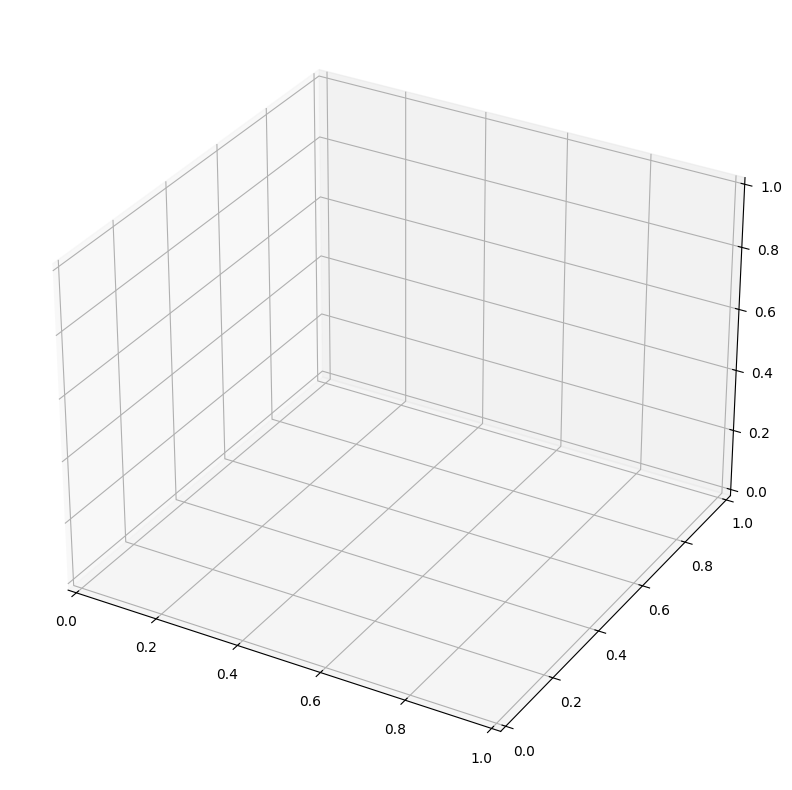

In [11]:
# Create and display animation (may take a moment)
print("Creating animation...")
anim = create_skeleton_animation(sample_trial, sample_angles, skip_frames=5, max_frames=100)
HTML(anim.to_jshtml())

## 4. Anatomical Range Validation

Check that computed angles stay within physiologically plausible ranges.

In [13]:
# Define anatomical limits (in degrees)
ANATOMICAL_LIMITS = {
    'elbow_r': (0, 160),      # Can't hyperextend, max flexion ~150-160
    'elbow_l': (0, 160),
    'knee_r': (0, 160),       # Similar to elbow
    'knee_l': (0, 160),
    'ankle_r': (50, 130),     # Dorsi/plantarflexion limits
    'ankle_l': (50, 130),
    'hip_r_flexion': (-45, 130),   # Extension to flexion
    'hip_l_flexion': (-45, 130),
    'hip_r_abduction': (-20, 60),  # Adduction to abduction
    'hip_l_abduction': (-20, 60),
    'shoulder_r_elevation': (-60, 200),  # Full range including overhead
    'shoulder_l_elevation': (-60, 200),
    'trunk_forward_lean': (-30, 90),     # Backward to forward lean
    'trunk_lateral_lean': (-45, 45),     # Side to side
}

def check_anatomical_limits(angles_df, limits=ANATOMICAL_LIMITS):
    """
    Check if angles stay within anatomical limits.
    
    Returns a dict with violation statistics for each joint.
    """
    results = {}
    
    for joint, (min_deg, max_deg) in limits.items():
        if joint not in angles_df.columns:
            continue
            
        angles_deg = np.degrees(angles_df[joint].values)
        
        below_min = angles_deg < min_deg
        above_max = angles_deg > max_deg
        
        results[joint] = {
            'min_observed': angles_deg.min(),
            'max_observed': angles_deg.max(),
            'mean': angles_deg.mean(),
            'std': angles_deg.std(),
            'limit_min': min_deg,
            'limit_max': max_deg,
            'violations_below': below_min.sum(),
            'violations_above': above_max.sum(),
            'violation_pct': (below_min.sum() + above_max.sum()) / len(angles_deg) * 100
        }
    
    return results

In [14]:
# Check limits for sample trial
limit_results = check_anatomical_limits(sample_angles)

print("Anatomical Limit Check Results")
print("=" * 80)
print(f"{'Joint':<25} {'Range':<15} {'Observed':<20} {'Violations':<15}")
print("-" * 80)

for joint, stats in limit_results.items():
    range_str = f"[{stats['limit_min']:.0f}, {stats['limit_max']:.0f}]"
    obs_str = f"[{stats['min_observed']:.1f}, {stats['max_observed']:.1f}]"
    viol_str = f"{stats['violation_pct']:.1f}%" if stats['violation_pct'] > 0 else "OK"
    
    # Highlight violations
    marker = "!!" if stats['violation_pct'] > 5 else ("!" if stats['violation_pct'] > 0 else "")
    
    print(f"{joint:<25} {range_str:<15} {obs_str:<20} {viol_str:<15} {marker}")

ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
# Check limits across ALL trials
print("\nChecking anatomical limits across ALL trials...")

all_violations = {}
trial_count = 0

for subject in subjects:
    for condition in conditions:
        for obstacles in raw_data['obstacles'].unique():
            trial = get_trial(subject, condition, obstacles)
            if len(trial) == 0:
                continue
            
            trial_count += 1
            angles = calculate_all_joint_angles(trial)
            results = check_anatomical_limits(angles)
            
            for joint, stats in results.items():
                if joint not in all_violations:
                    all_violations[joint] = []
                all_violations[joint].append({
                    'subject': subject,
                    'condition': condition,
                    'obstacles': obstacles,
                    'violation_pct': stats['violation_pct'],
                    'min_obs': stats['min_observed'],
                    'max_obs': stats['max_observed']
                })

print(f"Checked {trial_count} trials")

In [ ]:
# Summarize violations across all trials
print("\nViolation Summary Across All Trials")
print("=" * 70)
print(f"{'Joint':<25} {'Mean Viol%':<12} {'Max Viol%':<12} {'Min Obs':<12} {'Max Obs':<12}")
print("-" * 70)

for joint in sorted(all_violations.keys()):
    viol_pcts = [v['violation_pct'] for v in all_violations[joint]]
    min_obs = min(v['min_obs'] for v in all_violations[joint])
    max_obs = max(v['max_obs'] for v in all_violations[joint])
    
    mean_viol = np.mean(viol_pcts)
    max_viol = np.max(viol_pcts)
    
    marker = "!!" if mean_viol > 5 else ("!" if mean_viol > 1 else "")
    
    print(f"{joint:<25} {mean_viol:<12.2f} {max_viol:<12.2f} {min_obs:<12.1f} {max_obs:<12.1f} {marker}")

## 5. Continuity Check

Check for sudden jumps in angle values that might indicate calculation errors or marker dropouts.

In [ ]:
def check_continuity(angles_df, max_jump_deg=30, sampling_rate=300):
    """
    Check for sudden jumps in angle time series.
    
    Args:
        angles_df: DataFrame with joint angles
        max_jump_deg: Maximum expected frame-to-frame change in degrees
        sampling_rate: Recording rate in Hz
        
    Returns:
        Dict with jump statistics for each joint
    """
    results = {}
    
    angle_cols = [c for c in angles_df.columns if c not in ['frame', 'time']]
    
    for col in angle_cols:
        angles_deg = np.degrees(angles_df[col].values)
        
        # Calculate frame-to-frame differences
        diffs = np.abs(np.diff(angles_deg))
        
        # Find jumps exceeding threshold
        jumps = diffs > max_jump_deg
        jump_indices = np.where(jumps)[0]
        
        results[col] = {
            'max_jump': diffs.max() if len(diffs) > 0 else 0,
            'mean_jump': diffs.mean() if len(diffs) > 0 else 0,
            'n_large_jumps': jumps.sum(),
            'jump_indices': jump_indices,
            'jump_pct': jumps.sum() / len(diffs) * 100 if len(diffs) > 0 else 0
        }
    
    return results

In [ ]:
# Check continuity for sample trial
continuity_results = check_continuity(sample_angles)

print("Continuity Check (frame-to-frame jumps > 30°)")
print("=" * 60)
print(f"{'Joint':<25} {'Max Jump':<12} {'Mean Jump':<12} {'Large Jumps':<12}")
print("-" * 60)

for joint, stats in sorted(continuity_results.items()):
    marker = "!!" if stats['n_large_jumps'] > 10 else ("!" if stats['n_large_jumps'] > 0 else "")
    print(f"{joint:<25} {stats['max_jump']:<12.1f} {stats['mean_jump']:<12.2f} {stats['n_large_jumps']:<12} {marker}")

## 6. Angle Time Series Plots

In [ ]:
def plot_angle_timeseries(angles_df, title="Joint Angles Over Time"):
    """
    Plot all joint angles over time with anatomical limits.
    """
    angle_cols = [c for c in angles_df.columns if c not in ['frame', 'time']]
    n_angles = len(angle_cols)
    
    n_rows = (n_angles + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 3*n_rows))
    axes = axes.flatten()
    
    frames = angles_df['frame'].values if 'frame' in angles_df.columns else np.arange(len(angles_df))
    
    for i, col in enumerate(angle_cols):
        ax = axes[i]
        angles_deg = np.degrees(angles_df[col].values)
        
        ax.plot(frames, angles_deg, 'b-', linewidth=0.5, alpha=0.8)
        
        # Add anatomical limits if defined
        if col in ANATOMICAL_LIMITS:
            min_lim, max_lim = ANATOMICAL_LIMITS[col]
            ax.axhline(min_lim, color='r', linestyle='--', alpha=0.5, label='Limit')
            ax.axhline(max_lim, color='r', linestyle='--', alpha=0.5)
            ax.fill_between(frames, min_lim, max_lim, alpha=0.1, color='green')
        
        ax.set_title(col)
        ax.set_xlabel('Frame')
        ax.set_ylabel('Angle (°)')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(n_angles, len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    return fig

In [ ]:
# Plot time series for sample trial
fig = plot_angle_timeseries(sample_angles, 
                            title=f"Joint Angles - Subject {subjects[0]}, Condition {conditions[0]}")
plt.show()

In [ ]:
# Compare same subject across different conditions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pick key angles to compare
key_angles = ['knee_r', 'knee_l', 'hip_r_flexion', 'elbow_r']

for ax, angle_name in zip(axes.flatten(), key_angles):
    for condition in conditions:
        trial = get_trial(subjects[0], condition, 'uden')
        if len(trial) == 0:
            continue
        angles = calculate_all_joint_angles(trial)
        if angle_name in angles.columns:
            # Normalize time to percentage for comparison
            t = np.linspace(0, 100, len(angles))
            ax.plot(t, np.degrees(angles[angle_name]), label=f'Condition {condition}', alpha=0.7)
    
    ax.set_title(angle_name)
    ax.set_xlabel('Trial %')
    ax.set_ylabel('Angle (°)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Subject {subjects[0]} - Same angles across conditions', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Left/Right Symmetry Check

In [ ]:
def check_bilateral_symmetry(angles_df):
    """
    Check correlation between left and right side joints.
    
    High correlation suggests symmetric movement patterns.
    """
    bilateral_pairs = [
        ('elbow_r', 'elbow_l'),
        ('knee_r', 'knee_l'),
        ('ankle_r', 'ankle_l'),
        ('shoulder_r_elevation', 'shoulder_l_elevation'),
        ('shoulder_r_azimuth', 'shoulder_l_azimuth'),
        ('hip_r_flexion', 'hip_l_flexion'),
        ('hip_r_abduction', 'hip_l_abduction'),
    ]
    
    results = {}
    for r_joint, l_joint in bilateral_pairs:
        if r_joint in angles_df.columns and l_joint in angles_df.columns:
            corr = np.corrcoef(angles_df[r_joint], angles_df[l_joint])[0, 1]
            diff = np.abs(angles_df[r_joint] - angles_df[l_joint])
            results[f"{r_joint.replace('_r', '')}"] = {
                'correlation': corr,
                'mean_diff_deg': np.degrees(diff.mean()),
                'max_diff_deg': np.degrees(diff.max())
            }
    
    return results

In [ ]:
# Check symmetry for sample trial
symmetry_results = check_bilateral_symmetry(sample_angles)

print("Bilateral Symmetry Check")
print("=" * 60)
print(f"{'Joint':<25} {'Correlation':<15} {'Mean Diff':<15} {'Max Diff':<15}")
print("-" * 60)

for joint, stats in symmetry_results.items():
    print(f"{joint:<25} {stats['correlation']:<15.3f} {stats['mean_diff_deg']:<15.1f}° {stats['max_diff_deg']:<15.1f}°")

In [ ]:
# Plot left vs right for key joints
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

pairs = [('knee_r', 'knee_l'), ('elbow_r', 'elbow_l'), 
         ('hip_r_flexion', 'hip_l_flexion'), ('shoulder_r_elevation', 'shoulder_l_elevation')]

for ax, (r_joint, l_joint) in zip(axes.flatten(), pairs):
    if r_joint in sample_angles.columns and l_joint in sample_angles.columns:
        r_deg = np.degrees(sample_angles[r_joint])
        l_deg = np.degrees(sample_angles[l_joint])
        
        ax.scatter(r_deg, l_deg, alpha=0.3, s=1)
        
        # Add diagonal line (perfect symmetry)
        lims = [min(r_deg.min(), l_deg.min()), max(r_deg.max(), l_deg.max())]
        ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect symmetry')
        
        corr = np.corrcoef(r_deg, l_deg)[0, 1]
        ax.set_title(f"{r_joint.replace('_r', '')} (r={corr:.3f})")
        ax.set_xlabel('Right (°)')
        ax.set_ylabel('Left (°)')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.suptitle('Left vs Right Joint Angles', fontsize=14)
plt.tight_layout()
plt.show()

## 8. DTW Similarity Analysis

### Hypothesis Testing:
1. **Within-subject, same-condition** should be most similar
2. **Between-subject, constrained conditions** (control/fast) might be more similar than within-subject across conditions
3. **"Fun" condition** should show highest variability

In [ ]:
# Load existing DTW results if available
from pathlib import Path
import glob

results_dir = Path('hopscotch_results')
dtw_files = sorted(results_dir.glob('dtw_joint_angles_results_*.tsv'))

if dtw_files:
    latest_file = dtw_files[-1]
    print(f"Loading DTW results from: {latest_file}")
    dtw_results = pd.read_csv(latest_file, sep='\t')
    print(f"Loaded {len(dtw_results)} comparisons")
    print(f"Columns: {list(dtw_results.columns)}")
else:
    print("No existing DTW results found. Run dtw_analysis_joint_angles.py first.")
    dtw_results = None

In [ ]:
if dtw_results is not None:
    # Categorize comparisons
    dtw_results['comparison_type'] = 'other'
    
    # Same subject, same condition (within different obstacle levels)
    same_subj_same_cond = (
        (dtw_results['subject_1'] == dtw_results['subject_2']) & 
        (dtw_results['condition_1'] == dtw_results['condition_2'])
    )
    dtw_results.loc[same_subj_same_cond, 'comparison_type'] = 'same_subj_same_cond'
    
    # Same subject, different condition
    same_subj_diff_cond = (
        (dtw_results['subject_1'] == dtw_results['subject_2']) & 
        (dtw_results['condition_1'] != dtw_results['condition_2'])
    )
    dtw_results.loc[same_subj_diff_cond, 'comparison_type'] = 'same_subj_diff_cond'
    
    # Different subject, same condition
    diff_subj_same_cond = (
        (dtw_results['subject_1'] != dtw_results['subject_2']) & 
        (dtw_results['condition_1'] == dtw_results['condition_2'])
    )
    dtw_results.loc[diff_subj_same_cond, 'comparison_type'] = 'diff_subj_same_cond'
    
    print("Comparison type counts:")
    print(dtw_results['comparison_type'].value_counts())

In [ ]:
if dtw_results is not None:
    # Compare DTW distances by comparison type
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Box plot by comparison type
    ax = axes[0]
    comparison_types = ['same_subj_same_cond', 'same_subj_diff_cond', 'diff_subj_same_cond']
    data_to_plot = [dtw_results[dtw_results['comparison_type'] == ct]['dtw_distance'].dropna() 
                    for ct in comparison_types]
    
    bp = ax.boxplot(data_to_plot, labels=['Same Subj\nSame Cond', 'Same Subj\nDiff Cond', 'Diff Subj\nSame Cond'])
    ax.set_ylabel('DTW Distance')
    ax.set_title('DTW Distance by Comparison Type')
    ax.grid(True, alpha=0.3)
    
    # Add means
    means = [d.mean() for d in data_to_plot]
    for i, m in enumerate(means):
        ax.scatter([i+1], [m], color='red', marker='D', s=50, zorder=5, label='Mean' if i==0 else '')
    ax.legend()
    
    # By condition
    ax = axes[1]
    for cond in sorted(dtw_results['condition_1'].unique()):
        subset = dtw_results[
            (dtw_results['condition_1'] == cond) & 
            (dtw_results['comparison_type'] == 'diff_subj_same_cond')
        ]
        if len(subset) > 0:
            ax.hist(subset['dtw_distance'].dropna(), bins=30, alpha=0.5, label=f'Condition {cond}')
    
    ax.set_xlabel('DTW Distance')
    ax.set_ylabel('Count')
    ax.set_title('Between-Subject DTW by Condition')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
if dtw_results is not None:
    # Statistical summary
    print("\nDTW Distance Statistics by Comparison Type")
    print("=" * 70)
    
    summary = dtw_results.groupby('comparison_type')['dtw_distance'].agg(['count', 'mean', 'std', 'median'])
    print(summary.round(2))
    
    print("\n" + "=" * 70)
    print("DTW Distance Statistics by Condition (between-subject only)")
    print("=" * 70)
    
    between_subj = dtw_results[dtw_results['comparison_type'] == 'diff_subj_same_cond']
    cond_summary = between_subj.groupby('condition_1')['dtw_distance'].agg(['count', 'mean', 'std', 'median'])
    print(cond_summary.round(2))

In [ ]:
if dtw_results is not None:
    # Test hypothesis: within-subject < between-subject (for same condition)
    from scipy import stats
    
    print("\nHypothesis Test: Within-subject vs Between-subject DTW distances")
    print("=" * 70)
    
    for cond in sorted(dtw_results['condition_1'].unique()):
        within = dtw_results[
            (dtw_results['comparison_type'] == 'same_subj_same_cond') &
            (dtw_results['condition_1'] == cond)
        ]['dtw_distance'].dropna()
        
        between = dtw_results[
            (dtw_results['comparison_type'] == 'diff_subj_same_cond') &
            (dtw_results['condition_1'] == cond)
        ]['dtw_distance'].dropna()
        
        if len(within) > 0 and len(between) > 0:
            # Mann-Whitney U test (non-parametric)
            stat, p_value = stats.mannwhitneyu(within, between, alternative='less')
            
            print(f"\nCondition {cond}:")
            print(f"  Within-subject:  mean={within.mean():.2f}, n={len(within)}")
            print(f"  Between-subject: mean={between.mean():.2f}, n={len(between)}")
            print(f"  Mann-Whitney U test (within < between): p={p_value:.4f}")
            print(f"  Result: {'CONFIRMED' if p_value < 0.05 else 'NOT CONFIRMED'} (within-subject more similar)")

In [ ]:
if dtw_results is not None:
    # Visualize condition effects more clearly
    fig, ax = plt.subplots(figsize=(12, 6))
    
    conditions_list = sorted(dtw_results['condition_1'].unique())
    x_positions = np.arange(len(conditions_list))
    width = 0.35
    
    within_means = []
    within_stds = []
    between_means = []
    between_stds = []
    
    for cond in conditions_list:
        within = dtw_results[
            (dtw_results['comparison_type'] == 'same_subj_same_cond') &
            (dtw_results['condition_1'] == cond)
        ]['dtw_distance'].dropna()
        
        between = dtw_results[
            (dtw_results['comparison_type'] == 'diff_subj_same_cond') &
            (dtw_results['condition_1'] == cond)
        ]['dtw_distance'].dropna()
        
        within_means.append(within.mean() if len(within) > 0 else 0)
        within_stds.append(within.std() if len(within) > 0 else 0)
        between_means.append(between.mean() if len(between) > 0 else 0)
        between_stds.append(between.std() if len(between) > 0 else 0)
    
    bars1 = ax.bar(x_positions - width/2, within_means, width, yerr=within_stds, 
                   label='Within-subject', capsize=5, alpha=0.8)
    bars2 = ax.bar(x_positions + width/2, between_means, width, yerr=between_stds,
                   label='Between-subject', capsize=5, alpha=0.8)
    
    ax.set_xlabel('Condition')
    ax.set_ylabel('DTW Distance')
    ax.set_title('DTW Distance: Within vs Between Subject by Condition')
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f'Cond {c}' for c in conditions_list])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

## 9. Cross-Condition Analysis

Testing the hypothesis that between-subject similarity in constrained conditions (k, h) might exceed within-subject similarity when comparing across conditions (especially involving 'fun').

In [ ]:
if dtw_results is not None:
    # Create condition pair labels
    dtw_results['condition_pair'] = dtw_results.apply(
        lambda r: f"{r['condition_1']}-{r['condition_2']}" if r['condition_1'] <= r['condition_2'] 
                  else f"{r['condition_2']}-{r['condition_1']}", 
        axis=1
    )
    
    # Within-subject, cross-condition comparisons
    within_cross = dtw_results[dtw_results['comparison_type'] == 'same_subj_diff_cond']
    
    print("Within-Subject, Cross-Condition DTW Distances")
    print("=" * 60)
    
    cross_summary = within_cross.groupby('condition_pair')['dtw_distance'].agg(['count', 'mean', 'std', 'median'])
    print(cross_summary.round(2))

In [ ]:
if dtw_results is not None:
    # Compare: within-subject cross-condition vs between-subject same-condition
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Get unique condition pairs
    cross_cond_pairs = sorted(within_cross['condition_pair'].unique())
    same_cond = sorted(dtw_results['condition_1'].unique())
    
    all_categories = []
    all_means = []
    all_stds = []
    colors = []
    
    # Within-subject, cross-condition
    for pair in cross_cond_pairs:
        subset = within_cross[within_cross['condition_pair'] == pair]['dtw_distance'].dropna()
        if len(subset) > 0:
            all_categories.append(f'Within\n{pair}')
            all_means.append(subset.mean())
            all_stds.append(subset.std())
            colors.append('steelblue')
    
    # Between-subject, same-condition
    for cond in same_cond:
        subset = dtw_results[
            (dtw_results['comparison_type'] == 'diff_subj_same_cond') &
            (dtw_results['condition_1'] == cond)
        ]['dtw_distance'].dropna()
        if len(subset) > 0:
            all_categories.append(f'Between\n{cond}-{cond}')
            all_means.append(subset.mean())
            all_stds.append(subset.std())
            colors.append('coral')
    
    x = np.arange(len(all_categories))
    ax.bar(x, all_means, yerr=all_stds, capsize=5, color=colors, alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(all_categories, fontsize=9)
    ax.set_ylabel('DTW Distance')
    ax.set_title('Within-Subject Cross-Condition vs Between-Subject Same-Condition\n(Blue=Within-subj cross-cond, Orange=Between-subj same-cond)')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

## 10. Per-Subject Similarity Matrix

In [ ]:
if dtw_results is not None:
    # Create subject similarity matrix for a specific condition
    condition_to_plot = conditions[0]  # Change this to explore different conditions
    
    subset = dtw_results[
        (dtw_results['condition_1'] == condition_to_plot) &
        (dtw_results['condition_2'] == condition_to_plot) &
        (dtw_results['obstacles_1'] == dtw_results['obstacles_2'])  # Same obstacle level
    ]
    
    # Build matrix
    subjects_sorted = sorted(subjects)
    n_subj = len(subjects_sorted)
    sim_matrix = np.zeros((n_subj, n_subj))
    
    for _, row in subset.iterrows():
        s1, s2 = str(row['subject_1']), str(row['subject_2'])
        if s1 in subjects_sorted and s2 in subjects_sorted:
            i, j = subjects_sorted.index(s1), subjects_sorted.index(s2)
            sim_matrix[i, j] = row['dtw_distance']
            sim_matrix[j, i] = row['dtw_distance']  # Symmetric
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(sim_matrix, cmap='viridis_r')  # Reversed: darker = more similar
    
    ax.set_xticks(range(n_subj))
    ax.set_yticks(range(n_subj))
    ax.set_xticklabels(subjects_sorted, rotation=45, ha='right')
    ax.set_yticklabels(subjects_sorted)
    ax.set_xlabel('Subject')
    ax.set_ylabel('Subject')
    ax.set_title(f'DTW Distance Matrix - Condition {condition_to_plot}\n(Darker = More Similar)')
    
    plt.colorbar(im, ax=ax, label='DTW Distance')
    plt.tight_layout()
    plt.show()

## 11. Summary Report

In [ ]:
print("="*70)
print("JOINT ANGLE VERIFICATION SUMMARY")
print("="*70)

print("\n1. ANATOMICAL RANGE CHECK")
print("-"*40)
high_violation_joints = [j for j, stats in limit_results.items() if stats['violation_pct'] > 5]
if high_violation_joints:
    print(f"   WARNING: High violation rates (>5%) in: {high_violation_joints}")
else:
    print("   PASS: All joints within anatomical limits (sample trial)")

print("\n2. CONTINUITY CHECK")
print("-"*40)
high_jump_joints = [j for j, stats in continuity_results.items() if stats['n_large_jumps'] > 10]
if high_jump_joints:
    print(f"   WARNING: Large jumps detected in: {high_jump_joints}")
else:
    print("   PASS: Angle time series are continuous")

print("\n3. BILATERAL SYMMETRY")
print("-"*40)
low_corr_joints = [j for j, stats in symmetry_results.items() if stats['correlation'] < 0.5]
if low_corr_joints:
    print(f"   NOTE: Low L/R correlation in: {low_corr_joints}")
    print("   (This may be expected for asymmetric movements)")
else:
    print("   OK: Reasonable bilateral correlation")

if dtw_results is not None:
    print("\n4. DTW SIMILARITY HYPOTHESIS")
    print("-"*40)
    
    within_mean = dtw_results[dtw_results['comparison_type'] == 'same_subj_same_cond']['dtw_distance'].mean()
    between_mean = dtw_results[dtw_results['comparison_type'] == 'diff_subj_same_cond']['dtw_distance'].mean()
    
    if within_mean < between_mean:
        print(f"   CONFIRMED: Within-subject ({within_mean:.1f}) < Between-subject ({between_mean:.1f})")
    else:
        print(f"   INVESTIGATE: Within-subject ({within_mean:.1f}) >= Between-subject ({between_mean:.1f})")

print("\n" + "="*70)
print("Review the visualizations above for detailed inspection.")
print("="*70)